# 1. Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 2. Data loading

In [ ]:
import pandas as pd

df_match = pd.read_csv("../data/processed/clean_match.csv")
df_context = pd.read_csv("../data/processed/clean_context.csv")
df_tickets = pd.read_csv("../data/processed/clean_tickets.csv")
df_trends = pd.read_csv("../data/processed/clean_trends.csv")
df_articles = pd.read_csv("../data/processed/clean_articles.csv")
df_goals = pd.read_csv("../data/processed/clean_goals.csv")

print(df_match.head())
print(df_context.head())
print(df_tickets.head())
print(df_trends.head())
print(df_articles.head())
print(df_goals.head())

                    match_id  match_date kickoff_time_local match_date_utc  \
0  d0te6swsv2y99ywgugc2utbmc  2022-07-23           18:15:00    2022-07-23Z   
1  d256yo3eng04m0fu7b4sl7wno  2022-07-30           18:15:00    2022-07-30Z   
2  d3pqkck2grzx98jg4sofhp8us  2022-08-07           21:00:00    2022-08-07Z   
3  d4mn5ksbxuvnaww4pmommxhqs  2022-08-14           18:30:00    2022-08-14Z   
4  d5htdqmc8w72upys41sfxhfkk  2022-08-21           18:30:00    2022-08-21Z   

  kickoff_time_utc  matchday             competition_id  \
0        16:15:00Z       1.0  4zwgbb66rif2spcoeeol2motx   
1        16:15:00Z       2.0  4zwgbb66rif2spcoeeol2motx   
2        19:00:00Z       3.0  4zwgbb66rif2spcoeeol2motx   
3        16:30:00Z       4.0  4zwgbb66rif2spcoeeol2motx   
4        16:30:00Z       5.0  4zwgbb66rif2spcoeeol2motx   

             competition_name     season                  season_id  ...  \
0  Belgian Jupiler Pro League  2022/2023  5wj8l9y4s3484k6puwup793pw  ...   
1  Belgian Jupiler Pro L

In [3]:
print(f"\n=== Columns ===\n")
for name, dataframe in [
    ("df_match", df_match),
    ("df_context", df_context),
    ("df_tickets", df_tickets),
    ("df_trends", df_trends),
    ("df_articles", df_articles),
    ("df_goals", df_goals)
]:
    print(f"\n=== {name} ===")
    print(dataframe.columns.tolist())
    print(f"Shape: {dataframe.shape}")


=== Columns ===


=== df_match ===
['match_id', 'match_date', 'kickoff_time_local', 'match_date_utc', 'kickoff_time_utc', 'matchday', 'competition_id', 'competition_name', 'season', 'season_id', 'stage', 'home_team_id', 'home_team', 'home_team_code', 'away_team_id', 'away_team', 'away_team_code', 'venue', 'winner', 'result_home', 'goals_home_ht', 'goals_away_ht', 'goals_home_ft', 'goals_away_ft', 'is_home_match', 'last_result_vs_opponent', 'tickets_scanned']
Shape: (142, 27)

=== df_context ===
['match_id', 'match_date', 'weather_temp_max_c', 'weather_temp_min_c', 'weather_temp_mean_c', 'weather_precipitation_mm', 'weather_rain_mm', 'weather_snowfall_cm', 'weather_windspeed_max_kmh', 'weather_sunshine_hours', 'weather_code', 'weather_temp_deviation', 'weather_score', 'weather_description', 'has_promotion', 'promo_tickets_total', 'promo_valentijn_tickets', 'promo_1plus1_tickets', 'promo_bring_a_friend_tickets', 'promo_free_subscriber_tickets', 'promo_bondskaarten_tickets', 'promo_disco

# 3. Feature engineering (opponent)

In [ ]:

df_match['match_date'] = pd.to_datetime(df_match['match_date'], errors='coerce')
df_match = df_match.sort_values('match_date').reset_index(drop=True)

df_match['opponent'] = df_match.apply(
    lambda r: r['away_team'] if r['is_home_match'] else r['home_team'], axis=1
)

opponent_popularity = {
    'Club Brugge': 1, 'Anderlecht': 1, 'Mechelen': 1, 'Sint-Truiden': 1, 'Westerlo': 1,
    'Genk': 3, 'Union Saint-Gilloise': 3,
    'Antwerp': 2, 'Gent': 2, 'Standard Liège': 2, 'Cercle Brugge': 2,
    'Kortrijk': 2, 'Sporting Charleroi': 2, 'Zulte Waregem': 2,
    'Eupen': 2, 'KV Oostende': 2, 'Seraing': 2, 'RWDM': 2,
    'Beerschot': 2, 'Dender': 2, 'RAAL La Louvière': 2,
}
df_match['opponent_popularity_tier'] = df_match['opponent'].map(opponent_popularity).fillna(2)

df_temp = df_match[['match_id', 'match_date', 'opponent']].copy()
df_temp = df_temp.merge(df_tickets[['match_id', 'tickets_sold_total']], on='match_id', how='left')

def opp_historical_avg(df):
    avgs = []
    for i, row in df.iterrows():
        past = df[
            (df['opponent'] == row['opponent']) &
            (df['match_date'] < row['match_date'])
        ]
        if len(past) >= 2:
            avgs.append(past['tickets_sold_total'].mean())
        else:
            avgs.append(df['tickets_sold_total'].mean())
    return avgs

df_temp['opp_historical_avg'] = opp_historical_avg(df_temp)
df_match = df_match.merge(df_temp[['match_id', 'opp_historical_avg']], on='match_id', how='left')


goals_per_opp = (
    df_goals[df_goals['is_ohl_goal'] == True]
    .groupby('opponent')
    .size()
    .reset_index(name='opp_goals_scored')
)
df_match = df_match.merge(goals_per_opp, on='opponent', how='left')
df_match['opp_goals_scored'] = df_match['opp_goals_scored'].fillna(0)


result_map = {'W': 3, 'D': 1, 'L': 0}
df_match['last_result_encoded'] = (
    df_match['last_result_vs_opponent']
    .str[0]
    .map(result_map)
    .fillna(1)
)

# 4. Merge datasets

In [5]:
print(df_match.columns)
print(df_context.columns)
print(df_tickets.columns)

Index(['match_id', 'match_date', 'kickoff_time_local', 'match_date_utc',
       'kickoff_time_utc', 'matchday', 'competition_id', 'competition_name',
       'season', 'season_id', 'stage', 'home_team_id', 'home_team',
       'home_team_code', 'away_team_id', 'away_team', 'away_team_code',
       'venue', 'winner', 'result_home', 'goals_home_ht', 'goals_away_ht',
       'goals_home_ft', 'goals_away_ft', 'is_home_match',
       'last_result_vs_opponent', 'tickets_scanned', 'opponent',
       'opponent_popularity_tier', 'opp_historical_avg', 'opp_goals_scored',
       'last_result_encoded'],
      dtype='str')
Index(['match_id', 'match_date', 'weather_temp_max_c', 'weather_temp_min_c',
       'weather_temp_mean_c', 'weather_precipitation_mm', 'weather_rain_mm',
       'weather_snowfall_cm', 'weather_windspeed_max_kmh',
       'weather_sunshine_hours', 'weather_code', 'weather_temp_deviation',
       'weather_score', 'weather_description', 'has_promotion',
       'promo_tickets_total', 'pr

In [6]:
df = df_match[[
    'match_id', 'match_date', 'home_team', 'away_team', 'opponent',
    'opponent_popularity_tier',
    'opp_historical_avg',
    'opp_goals_scored',
    'last_result_encoded'
]]
df = df.merge(df_context.drop(columns=['match_date'], errors='ignore'), on='match_id', how='left')
df = df.merge(df_tickets[['match_id', 'tickets_sold_total']], on='match_id', how='left')
df = df.dropna(subset=['match_date', 'tickets_sold_total'])

# 5. Date features

In [7]:
df['match_date'] = pd.to_datetime(df['match_date'], errors='coerce')
df['weekday'] = df['match_date'].dt.weekday
df['month'] = df['match_date'].dt.month
df['is_weekend'] = (df['weekday'] >= 5).astype(int)

# 6. Features & target

In [8]:
print(df.columns)

Index(['match_id', 'match_date', 'home_team', 'away_team', 'opponent',
       'opponent_popularity_tier', 'opp_historical_avg', 'opp_goals_scored',
       'last_result_encoded', 'weather_temp_max_c', 'weather_temp_min_c',
       'weather_temp_mean_c', 'weather_precipitation_mm', 'weather_rain_mm',
       'weather_snowfall_cm', 'weather_windspeed_max_kmh',
       'weather_sunshine_hours', 'weather_code', 'weather_temp_deviation',
       'weather_score', 'weather_description', 'has_promotion',
       'promo_tickets_total', 'promo_valentijn_tickets',
       'promo_1plus1_tickets', 'promo_bring_a_friend_tickets',
       'promo_free_subscriber_tickets', 'promo_bondskaarten_tickets',
       'promo_discount_tickets', 'promotion_names', 'weekday', 'weekday_name',
       'is_weekend', 'is_midweek', 'academic_year', 'academic_week',
       'is_public_holiday', 'public_holiday_name',
       'is_school_holiday_flanders', 'school_holiday_name', 'pct_free_tickets',
       'campaign_motto', 'tickets_

In [9]:
features = [
    'opp_historical_avg',
    'opp_goals_scored',
    'last_result_encoded',
    'opponent_popularity_tier',
    'weekday',
    'month',
    'is_weekend',
    'weather_temp_mean_c',
    'weather_precipitation_mm',
    'weather_score',
    'has_promotion'
]

target = 'tickets_sold_total'

X = df[features]
y = df[target]

# 7. Train / test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8. Model training

In [11]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

# 9. Predictions

In [12]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 10. Evaluation

In [13]:
def evaluate(y_true, y_pred, set_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    median_ae = np.median(np.abs(y_true - y_pred))
    mean_pct_error = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"=== {set_name} ===")
    print(f"MAE: {mae:.2f}")
    print(f"Median AE: {median_ae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.3f}")
    print(f"Mean % error: {mean_pct_error:.1f}%")

    # Scatter plot: predicted vs actual
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', label='Perfect prediction')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{set_name}: Predicted vs Actual')
    plt.legend()
    plt.show()

    # Residual plot
    residuals = y_true - y_pred
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel('Predicted')
    plt.ylabel('Residuals')
    plt.title(f'{set_name}: Residuals')
    plt.show()

# 11. Evaluation

=== Train set ===
MAE: 465.25
Median AE: 305.02
RMSE: 603.37
R²: 0.655
Mean % error: 7.1%


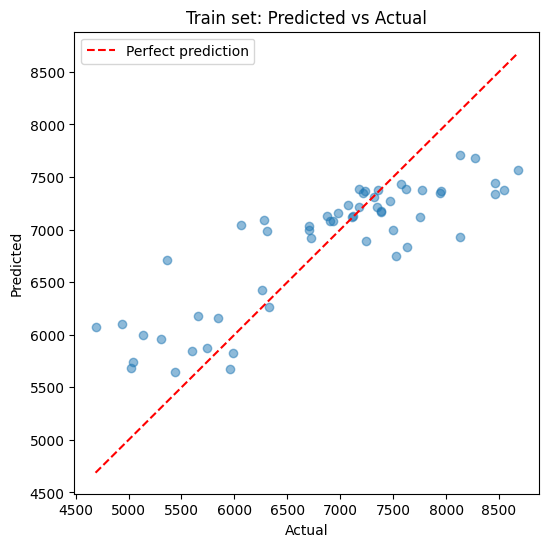

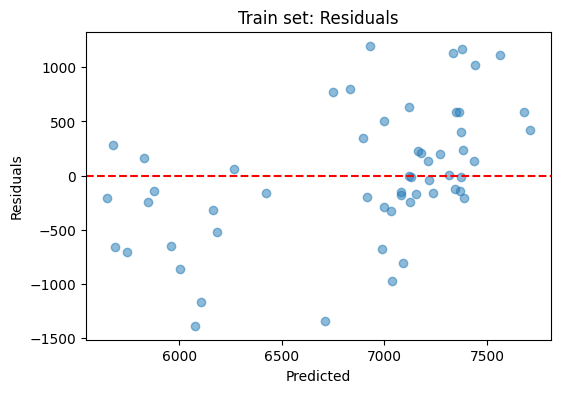

=== Test set ===
MAE: 935.94
Median AE: 1039.32
RMSE: 1033.56
R²: 0.195
Mean % error: 14.7%


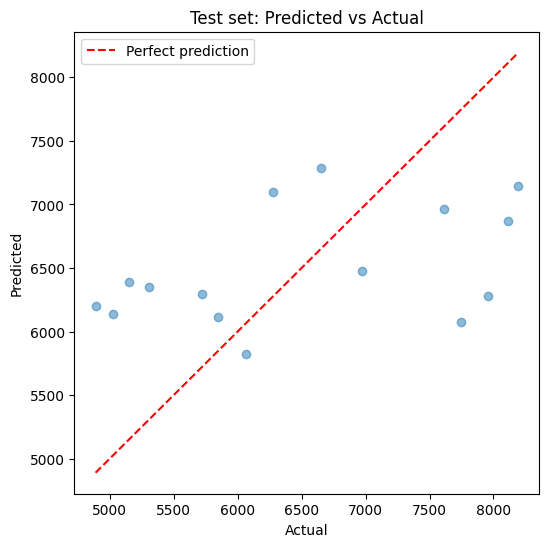

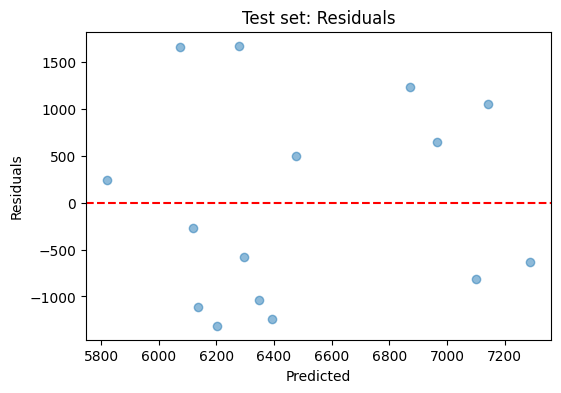

In [14]:
evaluate(y_train, y_train_pred, "Train set")
evaluate(y_test, y_test_pred, "Test set")

# 12. Analysis of each game

In [35]:
results = X_test.copy()
results['true'] = y_test                     # Add the actual ticket sales
results['pred'] = y_test_pred                # Add the predicted ticket sales
results['abs_error'] = abs(results['true'] - results['pred'])  # Absolute error
results['pct_error'] = np.where(
    results['true'] == 0,
    0,
    results['abs_error'] / results['true'] * 100               # Percent error
)

# Create a display table with relevant columns and rounded values
results_display = results[['true', 'pred', 'abs_error', 'pct_error']].copy()
results_display['abs_error'] = results_display['abs_error'].round(2)
results_display['pct_error'] = results_display['pct_error'].round(2)

# Top 5 best predictions (smallest absolute error)
print("\nTop 5 Best Predictions:")
print(results_display.nsmallest(5, 'abs_error').reset_index(drop=True))

# Top 5 worst predictions (largest absolute error)
print("\nTop 5 Worst Predictions:")
print(results_display.nlargest(5, 'abs_error').reset_index(drop=True))


Top 5 Best Predictions:
     true         pred  abs_error  pct_error
0  6069.0  5821.351968     247.65       4.08
1  5844.0  6117.696190     273.70       4.68
2  6975.0  6475.171333     499.83       7.17
3  5721.0  6294.842752     573.84      10.03
4  6652.0  7287.600110     635.60       9.56

Top 5 Worst Predictions:
     true         pred  abs_error  pct_error
0  7956.0  6278.360565    1677.64      21.09
1  7743.0  6074.800677    1668.20      21.54
2  4889.0  6202.204317    1313.20      26.86
3  5154.0  6392.505915    1238.51      24.03
4  8111.0  6873.439287    1237.56      15.26
